<a href="https://colab.research.google.com/github/Jinan-Bark/H-Copilot/blob/master/notebooks/Prediction_Model_Clean_Reproducible.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# H-Copilot Flow Prediction — Clean Final Build
This notebook rebuilds the final 15-feature blended model (Random Forest + Neural Network) directly, skipping all the rejected experiments. Upload your `ED_triage.csv` when prompted, then Run All.

## 1. Imports and upload data

In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

In [4]:
from google.colab import files
uploaded = files.upload()  # upload ED_triage.csv when prompted

Saving ED_triage.csv to ED_triage (1).csv


In [ ]:
df = pd.read_csv('ED_triage.csv')
print(df.columns.tolist())
print(df.shape)
df.head(3)

['triage_code', 'gender', 'age', 'admission_year', 'admission_month', 'admission_day', 'admission_weekday', 'admission_hour', 'kindref', 'ChiefComplaint', 'explainer_id', 'NeedFastExecute', 'CriticalStatus', 'StuporStatus', 'PainGrade', 'MentalDistress', 'MaterialDistress', 'Source', 'BlooddpressurSystol', 'BlooddpressurDiastol', 'PulseRate', 'RespiratoryRate', 'Temperature', 'O2Saturation', 'AVPU', 'TriageGrade', 'operational_patient', 'ref_specialist']
(143582, 28)


,triage_code,gender,age,admission_year,admission_month,admission_day,admission_weekday,admission_hour,kindref,ChiefComplaint,...,BlooddpressurSystol,BlooddpressurDiastol,PulseRate,RespiratoryRate,Temperature,O2Saturation,AVPU,TriageGrade,operational_patient,ref_specialist
0,13960101008,Female,77,2017,3,21,2,2,5,Z03.89,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,0,0
1,13960101009,Male,42,2017,3,21,2,2,6,T07,...,NaN,NaN,86.0,18.0,NaN,96.0,A,3,0,0
2,13960101010,Female,71,2017,3,21,2,2,6,R10.84,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0


## 2. Load and clean raw data

In [5]:
triage = pd.read_csv('ED_triage.csv')

# Remove duplicate triage_code rows (re-triage records of same visit), keep first
triage = triage.drop_duplicates(subset='triage_code', keep='first')

# Build proper date column
triage['date'] = pd.to_datetime(
    triage[['admission_year','admission_month','admission_day']]
    .rename(columns={'admission_year':'year','admission_month':'month','admission_day':'day'})
)

# day_of_week: 0=Sunday ... 6=Saturday (verified against real calendar earlier in project)
triage['day_of_week'] = (triage['date'].dt.dayofweek + 1) % 7

# Build hour_slot (0-5) from admission_hour — not pre-existing in the raw CSV
triage['hour_slot'] = triage['admission_hour'] // 4

print(f'Rows after dedup: {len(triage)}')
print(triage[['date','day_of_week','hour_slot']].head())

Rows after dedup: 143346
        date  day_of_week  hour_slot
0 2017-03-21            2          0
1 2017-03-21            2          0
2 2017-03-21            2          0
3 2017-03-21            2          0
4 2017-03-21            2          0


## 3. Keep only the clean, COVID-free continuous range
Data confirmed normal through Feb 21, 2020 (Iran's first COVID cases announced Feb 19, 2020; sharp arrival drop began Feb 22, 2020).

In [6]:
triage = triage[triage['date'] <= '2020-02-21'].copy()
print(f'Rows in clean range: {len(triage)}')
print(f'Date range: {triage["date"].min()} to {triage["date"].max()}')

Rows in clean range: 91490
Date range: 2017-03-21 00:00:00 to 2020-02-21 00:00:00


## 4. Build the slot-level patient_count table (the base for flow prediction)

In [7]:
base = (
    triage.groupby(['date','day_of_week','hour_slot'])
    .size()
    .reset_index(name='patient_count')
)
base = base.sort_values(['date','hour_slot']).reset_index(drop=True)
print(base.head())
print(f'Total slot-rows: {len(base)}')

        date  day_of_week  hour_slot  patient_count
0 2017-03-21            2          0              8
1 2017-03-21            2          1             11
2 2017-03-21            2          2             16
3 2017-03-21            2          3             21
4 2017-03-21            2          4             26
Total slot-rows: 6367


## 5. Build all 15 final features
Each one individually tested and validated earlier in the project.

In [8]:
# --- Historical patient-flow features ---
# Each weekday + 4-hour slot occurs approximately once per week.
# Therefore, rolling N observations represent approximately N previous weeks.

for weeks in [2, 4, 8, 12]:
    base[f'lag_{weeks}wk_avg'] = (
        base.groupby(['day_of_week', 'hour_slot'])['patient_count']
        .transform(
            lambda x: x.shift(1).rolling(
                weeks,
                min_periods=1
            ).mean()
        )
    )

# --- Same-day momentum ---
base['daily_cumulative_avg'] = base.groupby('date')['patient_count'].transform(lambda x: x.expanding().mean().shift(1))
base['daily_cumulative_avg'] = base['daily_cumulative_avg'].fillna(base['lag_8wk_avg'])

# --- Calendar ---
base['is_weekend'] = base['day_of_week'].isin([0,6]).astype(int)
base['month'] = pd.to_datetime(base['date']).dt.month
base['week_of_year'] = pd.to_datetime(base['date']).dt.isocalendar().week.astype(int)

def add_slot_feature(df, source_col, agg='mean', newname=None):
    name = newname or f'avg_{source_col}'
    agg_df = (
        triage.groupby(['date','hour_slot'])[source_col]
        .agg(agg)
        .reset_index()
        .rename(columns={source_col: name})
    )
    df = df.merge(agg_df, on=['date','hour_slot'], how='left')
    lagname = f'lag_8wk_{name}'
    df[lagname] = df.groupby(['day_of_week','hour_slot'])[name].transform(lambda x: x.shift(1).rolling(8, min_periods=1).mean())
    return df, lagname

base, sev_col = add_slot_feature(base, 'TriageGrade', newname='severity')
base, age_col = add_slot_feature(base, 'age')
base, pain_col = add_slot_feature(base, 'PainGrade')
base, fast_col = add_slot_feature(base, 'NeedFastExecute')
base, crit_col = add_slot_feature(base, 'CriticalStatus')

# --- High-acuity rate (Grade 1-2) ---
triage['is_high_acuity'] = (triage['TriageGrade'] <= 2).astype(int)
base, acuity_col = add_slot_feature(base, 'is_high_acuity', newname='high_acuity')

# --- Complaint-type mix (4 macro categories from ICD chapter letters) ---
triage['icd_chapter'] = triage['ChiefComplaint'].astype(str).str[0]
category_map = {
    'S':'Trauma/Injury','T':'Trauma/Injury','W':'Trauma/Injury',
    'R':'Medical/Internal','K':'Medical/Internal','N':'Medical/Internal',
    'I':'Medical/Internal','G':'Medical/Internal','E':'Medical/Internal','J':'Medical/Internal',
    'M':'Musculoskeletal/Skin','L':'Musculoskeletal/Skin',
    'Z':'Other/Administrative'
}
triage['complaint_macro'] = triage['icd_chapter'].map(category_map).fillna('Other/Administrative')

complaint_mix = (
    triage.groupby(['date','hour_slot','complaint_macro'])
    .size().unstack(fill_value=0).reset_index()
)
base = base.merge(complaint_mix, on=['date','hour_slot'], how='left')
for cat in ['Medical/Internal','Trauma/Injury']:  # the 2 categories kept in the final 15-feature set
    base[f'lag_8wk_{cat}'] = base.groupby(['day_of_week','hour_slot'])[cat].transform(lambda x: x.shift(1).rolling(8, min_periods=1).mean())

base = base.sort_values(['date','hour_slot']).reset_index(drop=True)
print('Feature build complete.')
print(base.columns.tolist())

Feature build complete.
['date', 'day_of_week', 'hour_slot', 'patient_count', 'lag_2wk_avg', 'lag_4wk_avg', 'lag_8wk_avg', 'lag_12wk_avg', 'daily_cumulative_avg', 'is_weekend', 'month', 'week_of_year', 'severity', 'lag_8wk_severity', 'avg_age', 'lag_8wk_avg_age', 'avg_PainGrade', 'lag_8wk_avg_PainGrade', 'avg_NeedFastExecute', 'lag_8wk_avg_NeedFastExecute', 'avg_CriticalStatus', 'lag_8wk_avg_CriticalStatus', 'high_acuity', 'lag_8wk_high_acuity', 'Medical/Internal', 'Musculoskeletal/Skin', 'Other/Administrative', 'Trauma/Injury', 'lag_8wk_Medical/Internal', 'lag_8wk_Trauma/Injury']


## 6. Train final deployable model (on ALL data — this is what gets saved)
The model is first evaluated using chronological walk-forward validation to measure performance on unseen future observations.

After completing the walk-forward evaluation, the final deployable Random Forest and Neural Network models are retrained using all available historical observations. These models are then saved for deployment.

In [9]:
feature_cols_15db = [
    'hour_slot', 'day_of_week', 'month', 'week_of_year', 'is_weekend',
    'lag_2wk_avg', 'lag_4wk_avg', 'lag_8wk_avg', 'lag_12wk_avg',
    'lag_8wk_severity', 'lag_8wk_high_acuity', 'daily_cumulative_avg',
    'lag_8wk_avg_PainGrade',
    'lag_8wk_Medical/Internal', 'lag_8wk_Trauma/Injury'
]
print(f'Total features: {len(feature_cols_15db)}')

# Evaluate with walk-forward, same as your official methodology
def walk_forward_15db(data, feature_cols, target_col, initial_train_frac=0.8, step_size=126):
    data = data.sort_values(['date','hour_slot']).reset_index(drop=True)
    data = data.dropna(subset=feature_cols).reset_index(drop=True)
    n = len(data)
    train_end = int(n * initial_train_frac)

    all_actuals, all_preds = [], []
    current_train_end = train_end
    while current_train_end < n:
        train_data = data.iloc[:current_train_end]
        step_end = min(current_train_end + step_size, n)
        test_step = data.iloc[current_train_end:step_end]

        X_tr, y_tr = train_data[feature_cols], train_data[target_col]
        X_te, y_te = test_step[feature_cols], test_step[target_col]

        scaler_wf = StandardScaler()
        X_tr_scaled = scaler_wf.fit_transform(X_tr)
        X_te_scaled = scaler_wf.transform(X_te)

        rf_wf = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
        rf_wf.fit(X_tr, y_tr)
        mlp_wf = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, learning_rate_init=0.01, max_iter=300, random_state=42, early_stopping=True, n_iter_no_change=5)
        mlp_wf.fit(X_tr_scaled, y_tr)

        preds = (rf_wf.predict(X_te) + mlp_wf.predict(X_te_scaled)) / 2
        all_actuals.extend(y_te.values)
        all_preds.extend(preds)
        current_train_end = step_end

    all_actuals, all_preds = np.array(all_actuals), np.array(all_preds)
    mae = mean_absolute_error(all_actuals, all_preds)
    rmse = np.sqrt(mean_squared_error(all_actuals, all_preds))
    nonzero_mask = all_actuals != 0

    mape = np.mean(
        np.abs(
            (all_actuals[nonzero_mask] - all_preds[nonzero_mask])
            / all_actuals[nonzero_mask]
        )
    ) * 100
    peak_thresh = np.quantile(all_actuals, 0.9)
    peak_mask = all_actuals >= peak_thresh
    peak_mae = mean_absolute_error(all_actuals[peak_mask], all_preds[peak_mask])
    print(f'Walk-forward (15 DB-compatible features) — MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%, Peak MAE: {peak_mae:.2f}')

walk_forward_15db(base, feature_cols_15db, 'patient_count')

# Now train the actual deployable model on ALL data
X_all_db = base.dropna(subset=feature_cols_15db)[feature_cols_15db]
y_all_db = base.dropna(subset=feature_cols_15db)['patient_count']

scaler_db = StandardScaler()
X_all_db_scaled = scaler_db.fit_transform(X_all_db)

rf_db = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
rf_db.fit(X_all_db, y_all_db)

mlp_db = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, learning_rate_init=0.01, max_iter=2000, random_state=42, early_stopping=True)
mlp_db.fit(X_all_db_scaled, y_all_db)

print('Final deployable model trained on all data.')

Total features: 15
Walk-forward (15 DB-compatible features) — MAE: 3.09, RMSE: 3.95, MAPE: 30.97%, Peak MAE: 6.15
Final deployable model trained on all data.


## 7. Save model and historical data for the backend

In [ ]:
joblib.dump({'rf': rf_db, 'mlp': mlp_db, 'scaler': scaler_db}, 'flow_prediction_model.pkl')

raw_cols = ['date','day_of_week','hour_slot','patient_count','severity','high_acuity',
            'avg_PainGrade','Medical/Internal','Trauma/Injury']
base[[c for c in raw_cols if c in base.columns]].to_csv('historical_flow_raw.csv', index=False)

files.download('flow_prediction_model.pkl')
files.download('historical_flow_raw.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### A0. Setup

In [ ]:
import os
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import BaseEstimator, RegressorMixin

# same 15 features as Section 6 (repeated so these cells still work after a runtime restart)
feature_cols_15db = [
    'hour_slot', 'day_of_week', 'month', 'week_of_year', 'is_weekend',
    'lag_2wk_avg', 'lag_4wk_avg', 'lag_8wk_avg', 'lag_12wk_avg',
    'lag_8wk_severity', 'lag_8wk_high_acuity', 'daily_cumulative_avg',
    'lag_8wk_avg_PainGrade',
    'lag_8wk_Medical/Internal', 'lag_8wk_Trauma/Injury'
]
import numpy as np, pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from google.colab import files

os.makedirs('figs', exist_ok=True)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})

def savefig(name):
    plt.tight_layout()
    plt.savefig(f'figs/{name}.png', dpi=200)
    plt.show()

### A1. Hourly arrivals (also reloads the full data)

In [ ]:
# Your notebook's Section 3 overwrote `triage` with the pre-COVID subset, so rebuild the FULL deduplicated data here
triage_full = pd.read_csv('ED_triage.csv').drop_duplicates(subset='triage_code', keep='first')
triage_full['date'] = pd.to_datetime(
    triage_full[['admission_year','admission_month','admission_day']]
    .rename(columns={'admission_year':'year','admission_month':'month','admission_day':'day'})
)
triage_full['day_of_week'] = (triage_full['date'].dt.dayofweek + 1) % 7   # 0=Sunday, same as your notebook
triage_full['hour_slot'] = triage_full['admission_hour'] // 4
print(f'Full deduplicated visits: {len(triage_full):,}')

# --- Hourly arrival pattern ---
hourly = triage_full.groupby('admission_hour').size()
fig, ax = plt.subplots(figsize=(9,4.5))
ax.bar(hourly.index, hourly.values, color='#4C72B0', edgecolor='black')
ax.set_xlabel('Hour of day'); ax.set_ylabel('Number of visits'); ax.set_title('Hourly arrival pattern (all years)')
ax.set_xticks(range(24))
savefig('eda_hourly')
print(f'Peak hour {hourly.idxmax()} ({hourly.max():,}); quietest hour {hourly.idxmin()} ({hourly.min():,})')

### A2. Monthly arrivals

In [ ]:
# --- Monthly arrival volumes ---
monthly = triage_full.groupby('admission_month').size()
fig, ax = plt.subplots(figsize=(9,4.5))
ax.bar(monthly.index, monthly.values, color='#C44E52', edgecolor='black')
ax.set_xlabel('Month'); ax.set_ylabel('Number of visits'); ax.set_title('Monthly arrival volumes (all years combined)')
ax.set_xticks(range(1,13))
savefig('eda_monthly')
print(f'Peak month {monthly.idxmax()} ({monthly.max():,}); quietest month {monthly.idxmin()} ({monthly.min():,})')

### A3. Yearly counts

In [ ]:
# --- Yearly visit counts ---
yearly = triage_full.groupby('admission_year').size()
fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(yearly.index.astype(str), yearly.values, color='#55A868', edgecolor='black')
ax.set_xlabel('Year'); ax.set_ylabel('Number of visits'); ax.set_title('Yearly visit counts (full dataset)')
savefig('eda_yearly')
print(yearly.to_string()); print('Sum:', f'{yearly.sum():,}')

### A4. Triage grade distribution

In [ ]:
# --- Triage grade (ESI) distribution ---
grades = triage_full['TriageGrade'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(grades.index.astype(int).astype(str), grades.values, color='#8172B2', edgecolor='black')
ax.set_xlabel('Triage grade (ESI level)'); ax.set_ylabel('Number of visits'); ax.set_title('Triage grade distribution')
savefig('eda_triage_grade')
print(grades.to_string()); print('Sum:', f'{grades.sum():,}')

### A5. 4-hour slot and weekday distribution

In [ ]:
# --- 4-hour slot distribution and weekday distribution ---
slots = triage_full.groupby('hour_slot').size()
labels = ['00-04','04-08','08-12','12-16','16-20','20-24']
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
axes[0].bar(labels, slots.values, color='#CCB974', edgecolor='black')
axes[0].set_xlabel('4-hour slot'); axes[0].set_ylabel('Number of visits'); axes[0].set_title('Visits per 4-hour slot')
wk = triage_full.groupby('day_of_week').size()
names = ['Sun','Mon','Tue','Wed','Thu','Fri','Sat']
axes[1].bar(names, wk.values, color='#64B5CD', edgecolor='black')
axes[1].set_xlabel('Day of week'); axes[1].set_title('Visits per weekday')
axes[1].set_ylim(0, wk.max()*1.15)
savefig('eda_slot_and_weekday')
print(slots.to_string()); print(wk.to_string())

### A6. Full time series with the COVID-19 boundary

In [ ]:
# --- Full time series with the COVID-19 exclusion boundary ---
daily = triage_full.groupby('date').size()
fig, ax = plt.subplots(figsize=(13,4.5))
ax.plot(daily.index, daily.values, color='#9DB4D1', linewidth=0.6, label='Daily visits')
ax.plot(daily.index, daily.rolling(7, center=True).mean(), color='#1F4E8C', linewidth=1.3, label='7-day average')
ax.axvline(pd.Timestamp('2020-02-21'), color='red', linestyle='--', linewidth=1.5, label='COVID-19 cutoff (21 Feb 2020)')
ax.set_xlabel('Date'); ax.set_ylabel('Visits per day'); ax.set_title('Full time series with COVID-19 exclusion boundary')
ax.legend()
savefig('eda_full_timeseries_covid')

### A7. Permutation feature importance

In [ ]:
data_m = base.sort_values(['date','hour_slot']).reset_index(drop=True).dropna(subset=feature_cols_15db).reset_index(drop=True)
split = int(len(data_m) * 0.8)
X_tr, y_tr = data_m.loc[:split-1, feature_cols_15db], data_m.loc[:split-1, 'patient_count']
X_te, y_te = data_m.loc[split:, feature_cols_15db],  data_m.loc[split:, 'patient_count']

class BlendModel(RegressorMixin, BaseEstimator):
    """50/50 RF + MLP blend with the same settings as the final model."""
    def fit(self, X, y):
        self.scaler = StandardScaler().fit(X)
        self.rf = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42).fit(X, y)
        self.mlp = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, learning_rate_init=0.01, max_iter=300,
                                random_state=42, early_stopping=True, n_iter_no_change=5).fit(self.scaler.transform(X), y)
        return self
    def predict(self, X):
        return (self.rf.predict(X) + self.mlp.predict(self.scaler.transform(X))) / 2

blend = BlendModel().fit(X_tr, y_tr)
print('Blend MAE on the held-out 20% (single fit, not walk-forward):', round(mean_absolute_error(y_te, blend.predict(X_te)), 3))

pi = permutation_importance(blend, X_te, y_te, scoring='neg_mean_absolute_error', n_repeats=20, random_state=42)
imp = pd.DataFrame({'feature': feature_cols_15db, 'mean': pi.importances_mean, 'std': pi.importances_std}).sort_values('mean')

fig, ax = plt.subplots(figsize=(9,6.5))
colors = ['#C44E52' if m < 0 else '#4C72B0' for m in imp['mean']]
ax.barh(imp['feature'], imp['mean'], xerr=imp['std'], color=colors, edgecolor='black', capsize=2)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Increase in MAE when the feature is shuffled (patients)')
ax.set_title('Permutation importance of the 15 features')
savefig('feature_importance')

pos = pd.Series(imp['mean'].clip(lower=0).values, index=imp['feature'].values)
share = (100 * pos / pos.sum()).sort_values(ascending=False).round(1)
print('Share of total (positive) importance, %:'); print(share.to_string())

### A8. Chronological 5-fold cross-validation (exact copy of your original CV)

In [ ]:
_all = base.sort_values(['date','hour_slot']).dropna(subset=feature_cols_15db).reset_index(drop=True)
clean_features = _all.iloc[:int(len(_all) * 0.8)].reset_index(drop=True)   # TRAINING portion only (first 80%); the final 20% test period is never touched
feature_cols = feature_cols_15db
print('all usable rows:', len(_all), '| rows used for CV (training portion):', len(clean_features), '(thesis split: 5,060 train / 1,265 test)')

tscv = TimeSeriesSplit(n_splits=5)
fold_results = []

for fold_num, (train_idx, test_idx) in enumerate(tscv.split(clean_features), 1):
    train_fold = clean_features.iloc[train_idx]
    test_fold = clean_features.iloc[test_idx]

    X_train_fold = train_fold[feature_cols]
    y_train_fold = train_fold['patient_count']
    X_test_fold = test_fold[feature_cols]
    y_test_fold = test_fold['patient_count']

    rf_fold = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42)
    rf_fold.fit(X_train_fold, y_train_fold)

    mlp_fold = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, learning_rate_init=0.01, max_iter=2000, random_state=42)
    mlp_fold.fit(X_train_fold, y_train_fold)

    y_pred_fold = (rf_fold.predict(X_test_fold) + mlp_fold.predict(X_test_fold)) / 2

    mae_fold = mean_absolute_error(y_test_fold, y_pred_fold)
    fold_results.append(mae_fold)
    print(f'Fold {fold_num}: MAE = {mae_fold:.2f} (train size: {len(train_fold)}, test size: {len(test_fold)})')

print(f'\nAverage MAE across 5 folds: {np.mean(fold_results):.2f}')
print(f'Standard deviation: {np.std(fold_results):.2f}')

# ---- figure ----
fig, ax = plt.subplots(figsize=(6,5))
ax.bar([f'Fold {i}' for i in range(1, 6)], fold_results, color='#4C72B0', edgecolor='black')
ax.axhline(np.mean(fold_results), color='red', linestyle='--', linewidth=1.2, label=f'Mean = {np.mean(fold_results):.2f}')
for i, v in enumerate(fold_results):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)
ax.set_ylabel('MAE (patients)'); ax.set_title('Chronological 5-fold cross-validation MAE')
ax.set_ylim(0, max(fold_results)*1.2); ax.legend()
savefig('cv_folds')

### A9a. Forecast data, QUICK option (no walk-forward)
Uses the blend already fitted in A7 (trained on the first 80%, predicting the final 20% in one go). The thesis found static and walk-forward results nearly identical (MAE 3.10 vs 3.12), so this is a fair preview,
but the figure titles will say *single fit* so nothing is mislabelled. For the walk-forward version, run A9b.

In [ ]:
test_part = data_m.loc[split:].reset_index(drop=True)
wf_df = pd.DataFrame({
    'date': pd.to_datetime(test_part['date']), 'hour_slot': test_part['hour_slot'].values,
    'actual': y_te.values, 'predicted': blend.predict(X_te)
})
forecast_label = 'Single-fit (first 80% train, last 20% test)'
print(forecast_label, '| test slots:', len(wf_df), '| MAE:', round(mean_absolute_error(wf_df['actual'], wf_df['predicted']), 3))

### A10. Forecast figures (run again after A9b if you use it)

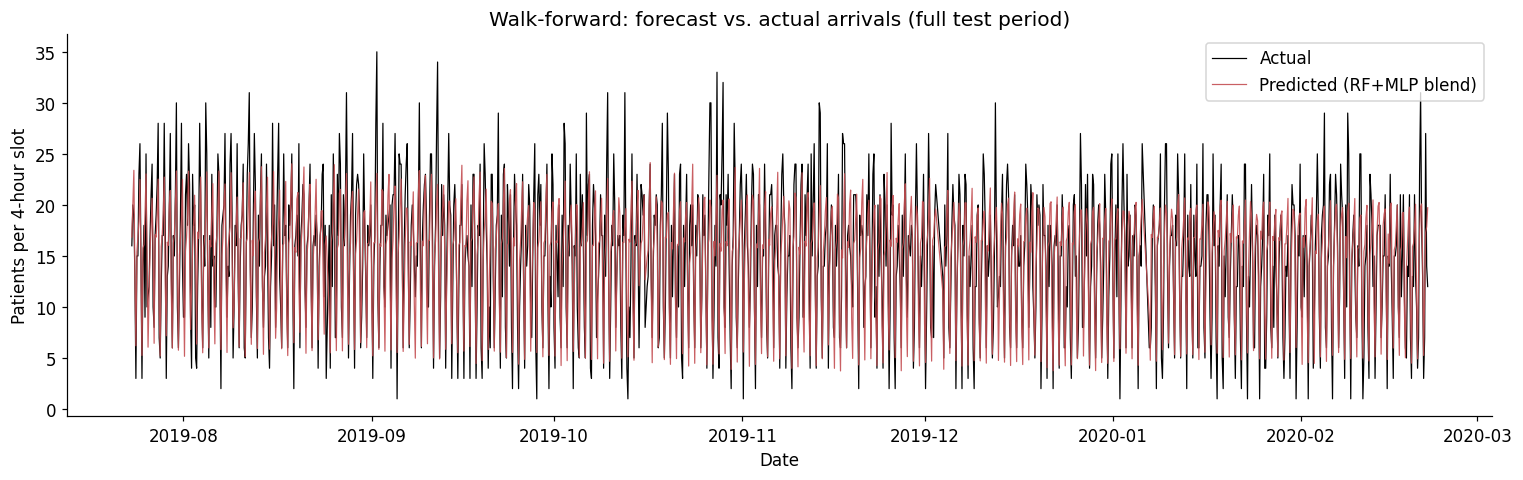

In [32]:
wf_df.to_csv('forecast_predictions.csv', index=False)
wf_df = wf_df.sort_values(['date','hour_slot']).reset_index(drop=True)
wf_df['t'] = wf_df['date'] + pd.to_timedelta(wf_df['hour_slot']*4, unit='h')
wf_df['error'] = wf_df['predicted'] - wf_df['actual']

# 1) Full test period
fig, ax = plt.subplots(figsize=(14,4.5))
ax.plot(wf_df['t'], wf_df['actual'], color='black', linewidth=0.8, label='Actual')
ax.plot(wf_df['t'], wf_df['predicted'], color='#C44E52', linewidth=0.8, alpha=0.9, label='Predicted (RF+MLP blend)')
ax.set_xlabel('Date'); ax.set_ylabel('Patients per 4-hour slot')
ax.set_title(f'{forecast_label}: forecast vs. actual arrivals (full test period)')
ax.legend()
savefig('forecast_full_period')

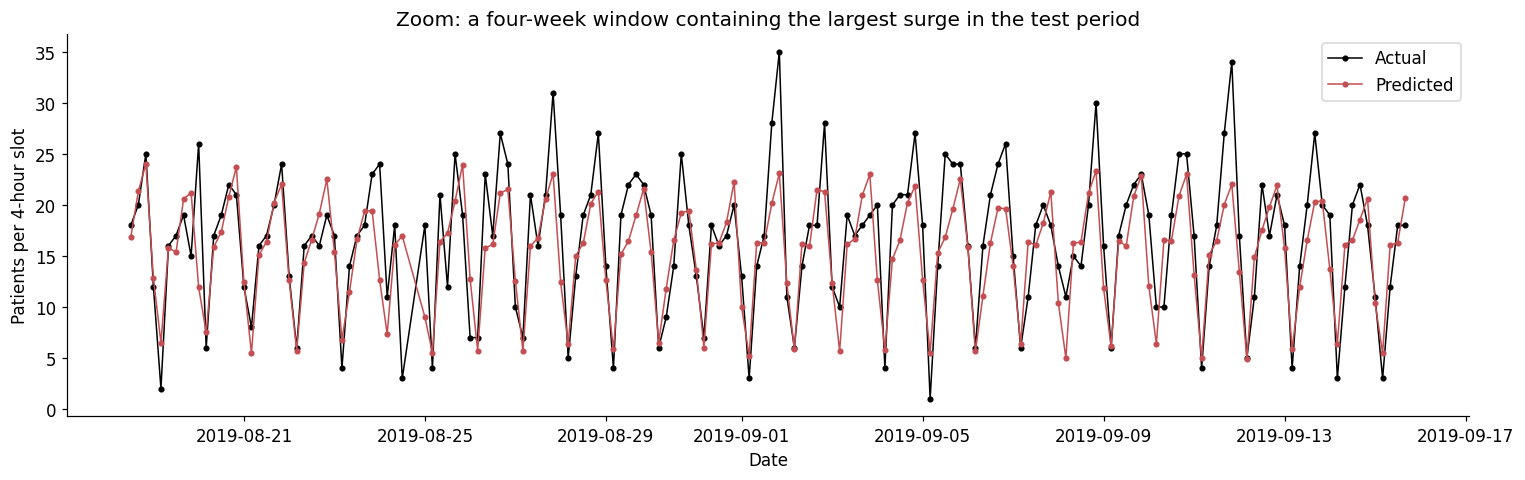

In [33]:
# 2) Zoom: 4-week window centred on the single largest actual surge
peak_i = int(wf_df['actual'].idxmax())
half = 84  # 84 slots = 14 days each side
lo = min(max(0, peak_i-half), max(0, len(wf_df)-2*half))   # always a full 28-day window, even near the ends
hi = min(len(wf_df), lo + 2*half)
w = wf_df.iloc[lo:hi]
fig, ax = plt.subplots(figsize=(14,4.5))
ax.plot(w['t'], w['actual'], color='black', marker='o', markersize=3, linewidth=1, label='Actual')
ax.plot(w['t'], w['predicted'], color='#C44E52', marker='o', markersize=3, linewidth=1, label='Predicted')
ax.set_xlabel('Date'); ax.set_ylabel('Patients per 4-hour slot')
ax.set_title('Zoom: a four-week window containing the largest surge in the test period')
ax.legend()
savefig('forecast_zoom_surge')

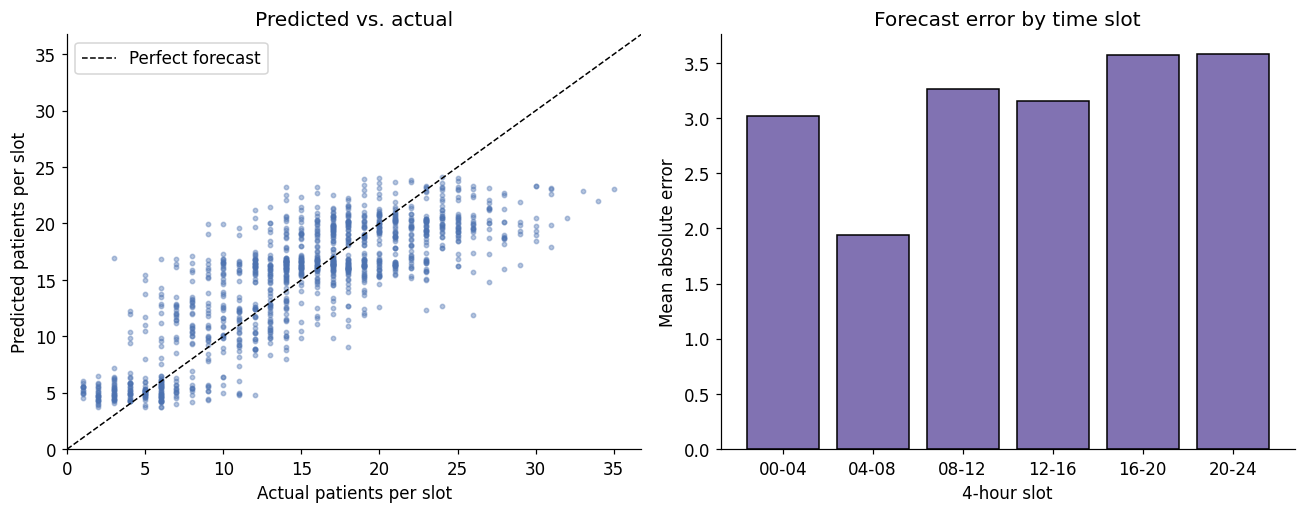

Mean signed error (bias): -0.11
Bias in the busiest 10% of slots: -6.15 (negative = under-forecasts surges)


In [34]:
# 3) Predicted vs actual scatter, and 4) error by time slot
fig, axes = plt.subplots(1, 2, figsize=(12,4.8))
axes[0].scatter(wf_df['actual'], wf_df['predicted'], s=8, alpha=0.4, color='#4C72B0')
lim = [0, max(wf_df['actual'].max(), wf_df['predicted'].max())*1.05]
axes[0].plot(lim, lim, color='black', linestyle='--', linewidth=1, label='Perfect forecast')
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel('Actual patients per slot'); axes[0].set_ylabel('Predicted patients per slot')
axes[0].set_title('Predicted vs. actual'); axes[0].legend()

by_slot = wf_df.groupby('hour_slot')['error'].apply(lambda e: e.abs().mean())
axes[1].bar(['00-04','04-08','08-12','12-16','16-20','20-24'], by_slot.values, color='#8172B2', edgecolor='black')
axes[1].set_xlabel('4-hour slot'); axes[1].set_ylabel('Mean absolute error'); axes[1].set_title('Forecast error by time slot')
savefig('forecast_scatter_and_slot_error')

print('Mean signed error (bias):', round(wf_df['error'].mean(), 3))
top = wf_df['actual'] >= wf_df['actual'].quantile(0.9)
print('Bias in the busiest 10% of slots:', round(wf_df.loc[top,'error'].mean(), 3), '(negative = under-forecasts surges)')

### A9b. OPTIONAL: true walk-forward predictions (slow, same cost as original walk-forward)
Identical to Section 6 function (same features, models, seeds, step size) except it **keeps the predictions**. `n_jobs=-1` only makes the Random Forest train on all CPU cores; with a fixed `random_state` the forest is identical, so results do not change.
Then re-run A10 to redraw the forecast figures from walk-forward.

In [31]:
def walk_forward_collect(data, feature_cols, target_col, initial_train_frac=0.8, step_size=126):
    data = data.sort_values(['date','hour_slot']).reset_index(drop=True)
    data = data.dropna(subset=feature_cols).reset_index(drop=True)
    n = len(data)
    train_end = int(n * initial_train_frac)
    acts, preds_all, dts, slots = [], [], [], []
    current_train_end = train_end
    while current_train_end < n:
        train_data = data.iloc[:current_train_end]
        step_end = min(current_train_end + step_size, n)
        test_step = data.iloc[current_train_end:step_end]
        X_tr_, y_tr_ = train_data[feature_cols], train_data[target_col]
        X_te_, y_te_ = test_step[feature_cols], test_step[target_col]
        sc = StandardScaler(); X_tr_s = sc.fit_transform(X_tr_); X_te_s = sc.transform(X_te_)
        rf_ = RandomForestRegressor(n_estimators=200, max_depth=6, criterion='absolute_error', random_state=42, n_jobs=-1).fit(X_tr_, y_tr_)
        mlp_ = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, learning_rate_init=0.01, max_iter=300, random_state=42, early_stopping=True, n_iter_no_change=5).fit(X_tr_s, y_tr_)
        p = (rf_.predict(X_te_) + mlp_.predict(X_te_s)) / 2
        acts.extend(y_te_.values); preds_all.extend(p); dts.extend(test_step['date'].values); slots.extend(test_step['hour_slot'].values)
        current_train_end = step_end
    a, p = np.array(acts), np.array(preds_all)
    nz = a != 0
    print(f"Walk-forward - MAE: {mean_absolute_error(a,p):.2f}, RMSE: {np.sqrt(mean_squared_error(a,p)):.2f}, "
          f"MAPE: {np.mean(np.abs((a[nz]-p[nz])/a[nz]))*100:.2f}%, WAPE: {100*np.sum(np.abs(a-p))/np.sum(a):.2f}%, "
          f"Peak MAE: {mean_absolute_error(a[a>=np.quantile(a,0.9)], p[a>=np.quantile(a,0.9)]):.2f}")
    return pd.DataFrame({'date': pd.to_datetime(dts), 'hour_slot': slots, 'actual': a, 'predicted': p})

wf_df = walk_forward_collect(base, feature_cols_15db, 'patient_count')
forecast_label = 'Walk-forward'
# now re-run A10 to redraw the three forecast figures from these predictions

Walk-forward - MAE: 3.09, RMSE: 3.95, MAPE: 30.97%, WAPE: 20.62%, Peak MAE: 6.15


### A11. Zip and download everything

In [ ]:
import shutil
shutil.make_archive('thesis_figures', 'zip', 'figs')
files.download('thesis_figures.zip')
files.download('forecast_predictions.csv')